# Sepsis Early Detection Model: A NEWS2-Based ML Approach
---
**Author:** Muhammed Omarjee (MBBS, King's College London 2023)

**Objective:** Build and evaluate machine learning models that predict sepsis onset from NEWS2 vital signs and routine laboratory markers, comparing multiple algorithms with clinically relevant evaluation metrics.

**Clinical context:** The UK National Early Warning Score (NEWS2) is a standardised tool for detecting acute deterioration. This project investigates whether ML models trained on NEWS2 parameters plus common labs (WCC, lactate, CRP) can flag sepsis risk earlier than the aggregate NEWS2 score alone.

> ⚠️ **Disclaimer:** This project uses synthetic data for educational and portfolio purposes. It is not a validated clinical decision-support tool.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
RANDOM_STATE = 42
print("All imports loaded successfully.")

All imports loaded successfully.


## 1. Data Loading & Overview

The dataset contains 2,000 synthetic patients with a 20% sepsis prevalence, generated with physiologically plausible vital-sign distributions derived from published NEWS2 reference ranges (RCP, 2017) and Sepsis-3 criteria (Singer et al., JAMA 2016).

In [2]:
df = pd.read_csv("../data/raw/sepsis_cohort.csv")
print(f"Dataset shape: {df.shape}")
print(f"Sepsis prevalence: {df['sepsis_onset'].mean():.1%}\n")
df.head(10)

Dataset shape: (2000, 15)
Sepsis prevalence: 20.0%



,patient_id,age,sex,resp_rate,spo2,heart_rate,systolic_bp,temperature,avpu,on_supplemental_o2,news2_score,wcc,lactate,crp,sepsis_onset
0,P0000,45,F,20,93,87,102,39.0,A,0,4,7.5,1.9,21.4,1
1,P0001,63,M,22,93,120,128,37.5,A,0,6,12.7,4.5,51.9,0
2,P0002,55,F,14,96,87,111,36.3,A,0,0,11.6,3.3,71.2,0
3,P0003,38,M,17,97,68,150,37.3,A,0,0,13.7,2.6,12.7,0
4,P0004,63,F,23,90,100,89,37.7,A,1,9,17.1,6.3,80.6,0
5,P0005,49,F,22,98,81,134,36.2,A,0,2,8.7,0.7,4.1,0
6,P0006,63,M,24,95,106,109,37.4,A,0,5,13.6,3.1,110.0,0
7,P0007,46,F,14,100,74,140,36.9,A,0,0,10.1,1.3,11.9,0
8,P0008,69,F,17,96,89,109,38.7,A,1,2,8.8,3.0,49.6,1
9,P0009,44,M,19,95,87,140,37.0,A,1,1,10.4,1.2,17.8,0


In [3]:
df.describe().round(2)

,age,resp_rate,spo2,heart_rate,systolic_bp,temperature,on_supplemental_o2,news2_score,wcc,lactate,crp,sepsis_onset
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.0
mean,54.73,19.80,95.42,87.28,116.64,37.06,0.31,3.33,10.46,2.20,39.90,0.2
std,11.55,4.43,2.82,16.83,17.24,0.77,0.46,3.59,3.90,1.16,36.09,0.4
min,23.00,8.00,86.00,40.00,60.00,34.00,0.00,0.00,0.50,0.30,1.50,0.0
25%,47.00,16.00,94.00,76.00,105.00,36.60,0.00,0.00,7.90,1.40,16.60,0.0
50%,54.00,20.00,96.00,86.00,117.00,36.90,0.00,2.00,10.40,2.00,29.40,0.0
75%,62.00,23.00,97.00,98.00,128.25,37.30,1.00,5.00,13.00,2.72,51.50,0.0
max,89.00,34.00,100.00,138.00,171.00,40.50,1.00,16.00,23.80,9.90,383.90,1.0


In [4]:
df.info()
print(f"\nMissing values:\n{df.isnull().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          2000 non-null   str    
 1   age                 2000 non-null   int64  
 2   sex                 2000 non-null   str    
 3   resp_rate           2000 non-null   int64  
 4   spo2                2000 non-null   int64  
 5   heart_rate          2000 non-null   int64  
 6   systolic_bp         2000 non-null   int64  
 7   temperature         2000 non-null   float64
 8   avpu                2000 non-null   str    
 9   on_supplemental_o2  2000 non-null   int64  
 10  news2_score         2000 non-null   int64  
 11  wcc                 2000 non-null   float64
 12  lactate             2000 non-null   float64
 13  crp                 2000 non-null   float64
 14  sepsis_onset        2000 non-null   int64  
dtypes: float64(4), int64(8), str(3)
memory usage: 248.2 KB

Missing va

## 2. Exploratory Data Analysis

### 2.1 Target Distribution

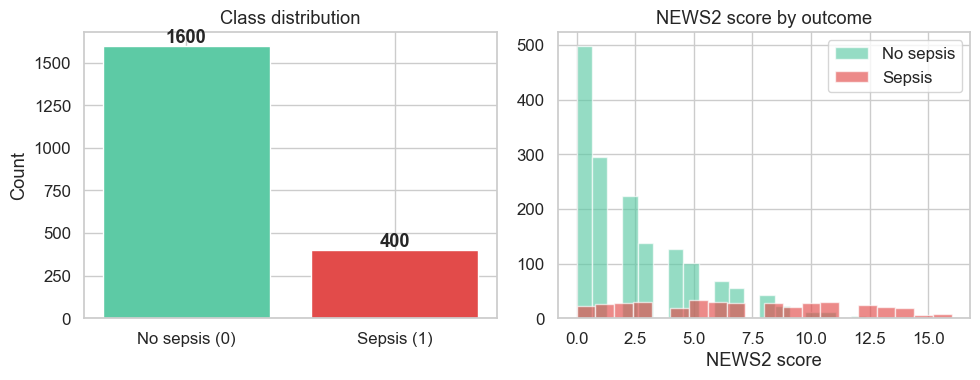

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['sepsis_onset'].value_counts()
colors = ['#5DCAA5', '#E24B4A']
axes[0].bar(['No sepsis (0)', 'Sepsis (1)'], counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

for label, colour, name in [(0, '#5DCAA5', 'No sepsis'), (1, '#E24B4A', 'Sepsis')]:
    subset = df[df['sepsis_onset'] == label]['news2_score']
    axes[1].hist(subset, bins=20, alpha=0.65, color=colour, label=name, edgecolor='white')
axes[1].set_title('NEWS2 score by outcome')
axes[1].set_xlabel('NEWS2 score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Vital Signs Distributions by Outcome

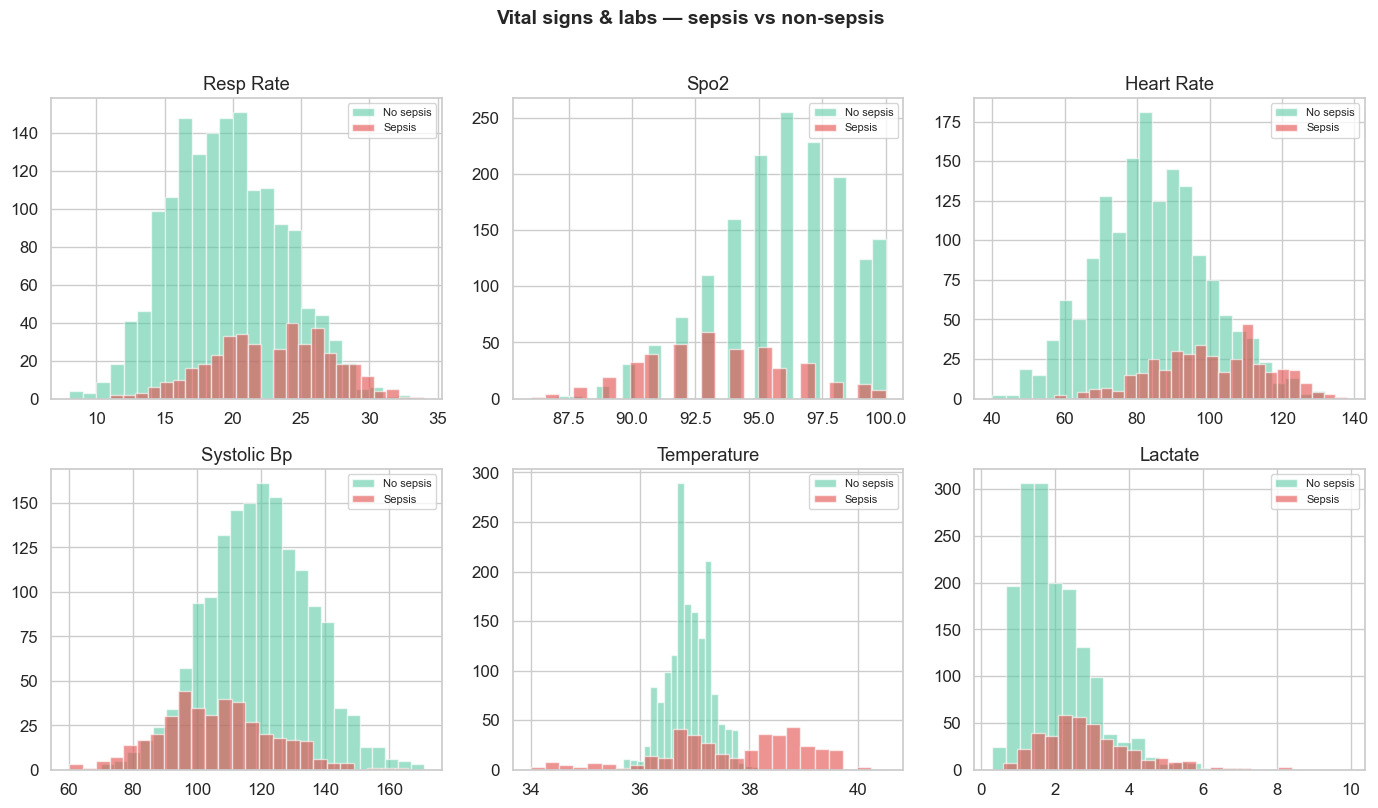

In [6]:
vitals = ['resp_rate', 'spo2', 'heart_rate', 'systolic_bp', 'temperature', 'lactate']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), vitals):
    for label, colour, name in [(0, '#5DCAA5', 'No sepsis'), (1, '#E24B4A', 'Sepsis')]:
        subset = df[df['sepsis_onset'] == label][col]
        ax.hist(subset, bins=25, alpha=0.6, color=colour, label=name, edgecolor='white')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=8)

plt.suptitle('Vital signs & labs — sepsis vs non-sepsis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/vitals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Correlation Matrix

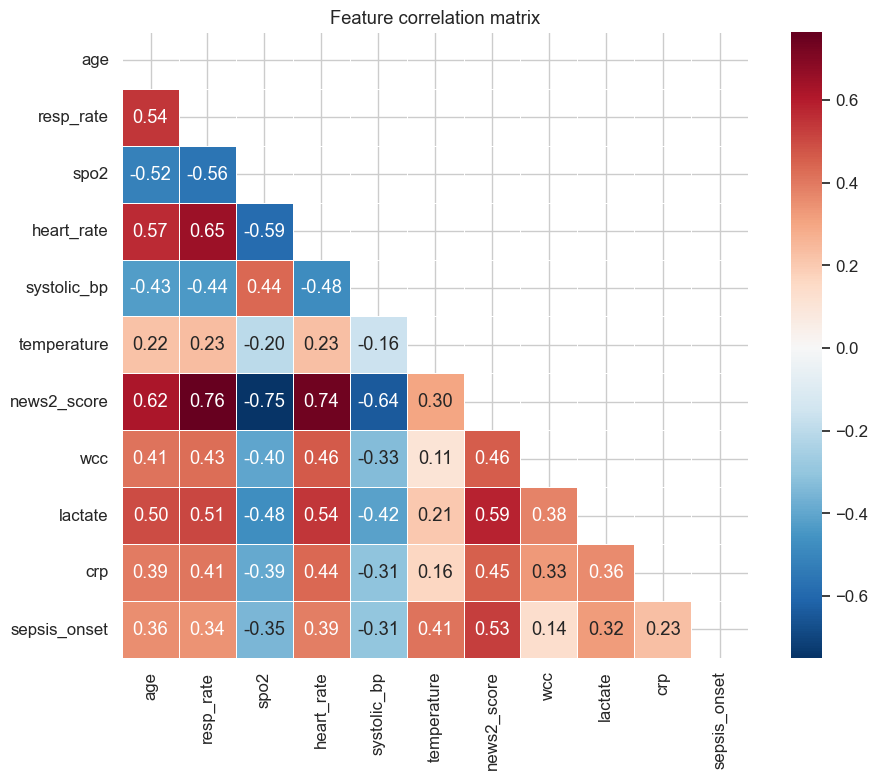

In [7]:
numeric_cols = ['age', 'resp_rate', 'spo2', 'heart_rate', 'systolic_bp',
                'temperature', 'news2_score', 'wcc', 'lactate', 'crp', 'sepsis_onset']

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('../assets/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Key Clinical Observations

The synthetic data exhibits expected clinical patterns:
- Sepsis patients show higher respiratory rates, heart rates, and temperatures
- SpO2 and systolic BP are lower in the sepsis group
- Lactate, WCC, and CRP are elevated — consistent with an inflammatory / organ dysfunction picture
- NEWS2 scores separate the groups well, but there is meaningful overlap in the 4–8 range

## 3. Preprocessing & Feature Engineering

In [8]:
le_avpu = LabelEncoder()
df['avpu_encoded'] = le_avpu.fit_transform(df['avpu'])

le_sex = LabelEncoder()
df['sex_encoded'] = le_sex.fit_transform(df['sex'])

feature_cols = [
    'age', 'sex_encoded', 'resp_rate', 'spo2', 'heart_rate',
    'systolic_bp', 'temperature', 'avpu_encoded',
    'on_supplemental_o2', 'news2_score', 'wcc', 'lactate', 'crp'
]

X = df[feature_cols].copy()
y = df['sepsis_onset'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print(f"Training set: {X_train.shape[0]} samples ({y_train.mean():.1%} sepsis)")
print(f"Test set:     {X_test.shape[0]} samples ({y_test.mean():.1%} sepsis)")

Training set: 1600 samples (20.0% sepsis)
Test set:     400 samples (20.0% sepsis)


## 4. Model Training & Comparison

We compare three algorithms of increasing complexity:

| Model | Rationale |
|-------|-----------|
| **Logistic Regression** | Interpretable baseline; standard in clinical risk scores |
| **Random Forest** | Handles non-linear interactions; robust to outliers |
| **Gradient Boosting** | State-of-the-art tabular performance; captures complex patterns |

All models use stratified 5-fold cross-validation on the training set, with final evaluation on the held-out test set.

In [9]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE, C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        min_samples_leaf=10, random_state=RANDOM_STATE
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("5-fold cross-validation AUROC on training set:")
print("-" * 50)
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    print(f"{name:25s}  {scores.mean():.4f} +/- {scores.std():.4f}")

5-fold cross-validation AUROC on training set:
--------------------------------------------------
Logistic Regression        0.8408 +/- 0.0211
Random Forest              0.8984 +/- 0.0189
Gradient Boosting          0.8834 +/- 0.0136


In [10]:
results = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'auroc': roc_auc_score(y_test, y_prob),
        'auprc': average_precision_score(y_test, y_prob),
        'brier': brier_score_loss(y_test, y_prob),
    }

summary = pd.DataFrame({
    name: {'AUROC': r['auroc'], 'AUPRC': r['auprc'], 'Brier Score': r['brier']}
    for name, r in results.items()
}).round(4).T

print("\nTest Set Performance Summary")
print("=" * 55)
print(summary.to_string())


Test Set Performance Summary
                      AUROC   AUPRC  Brier Score
Logistic Regression  0.8945  0.8085       0.1253
Random Forest        0.9060  0.8625       0.0842
Gradient Boosting    0.8870  0.8443       0.0620


In [11]:
# Bootstrap 95% confidence intervals for AUROC and AUPRC
# -----------------------------------------------------
# Why: a single AUROC value hides how much it might vary on a different
# patient sample. Bootstrap resampling (sampling with replacement from the
# test set) gives us a plausible range for how the model would perform on
# similar patients. Standard practice in clinical ML papers.

from sklearn.utils import resample

def bootstrap_ci(y_true, y_prob, metric_fn, n_bootstrap=1000, seed=42):
    """Return (lower, median, upper) 95% CI for a given metric."""
    rng = np.random.default_rng(seed)
    y_true_arr = np.asarray(y_true)
    y_prob_arr = np.asarray(y_prob)
    scores = []
    n = len(y_true_arr)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        # Skip resamples that happen to contain only one class
        if len(np.unique(y_true_arr[idx])) < 2:
            continue
        scores.append(metric_fn(y_true_arr[idx], y_prob_arr[idx]))
    return np.percentile(scores, [2.5, 50, 97.5])

print(f"{'Model':<22s}  {'AUROC (95% CI)':<25s}  {'AUPRC (95% CI)'}")
print("-" * 80)
for name, r in results.items():
    lo_auc, med_auc, hi_auc = bootstrap_ci(y_test, r['y_prob'], roc_auc_score)
    lo_ap, med_ap, hi_ap = bootstrap_ci(y_test, r['y_prob'], average_precision_score)
    print(f"{name:<22s}  {med_auc:.3f} ({lo_auc:.3f}–{hi_auc:.3f})   "
          f"{med_ap:.3f} ({lo_ap:.3f}–{hi_ap:.3f})")

Model                   AUROC (95% CI)             AUPRC (95% CI)
--------------------------------------------------------------------------------
Logistic Regression     0.896 (0.843–0.941)   0.810 (0.729–0.878)
Random Forest           0.907 (0.849–0.950)   0.864 (0.791–0.917)
Gradient Boosting       0.889 (0.828–0.939)   0.847 (0.772–0.904)


## 5. Evaluation Plots

### 5.1 ROC & Precision-Recall Curves

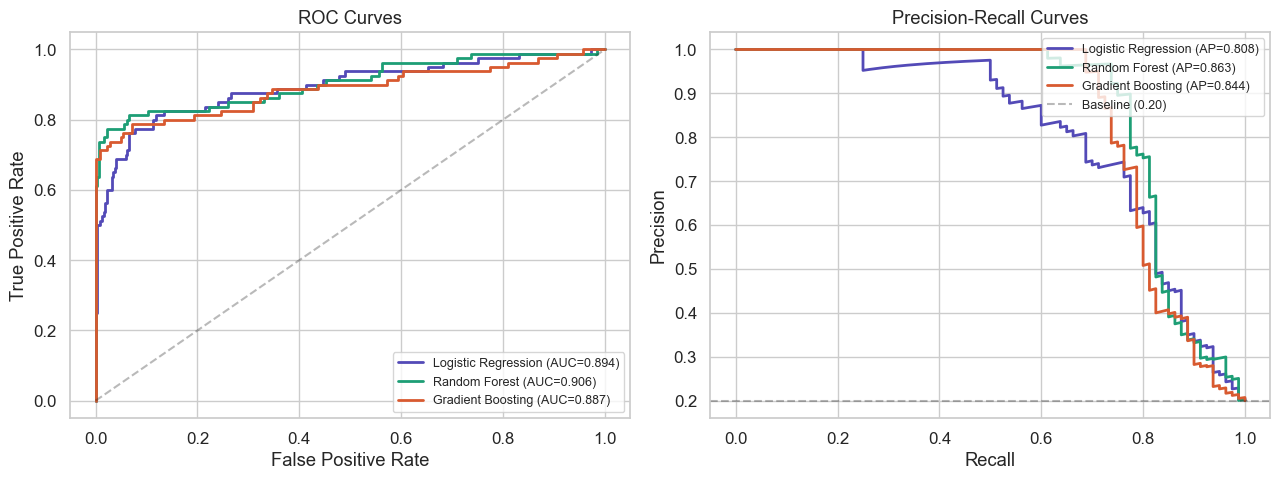

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colours = ['#534AB7', '#1D9E75', '#D85A30']

for (name, r), c in zip(results.items(), colours):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['auroc']:.3f})", color=c, linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right', fontsize=9)

for (name, r), c in zip(results.items(), colours):
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    axes[1].plot(rec, prec, label=f"{name} (AP={r['auprc']:.3f})", color=c, linewidth=2)
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.3, label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../assets/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Confusion Matrices

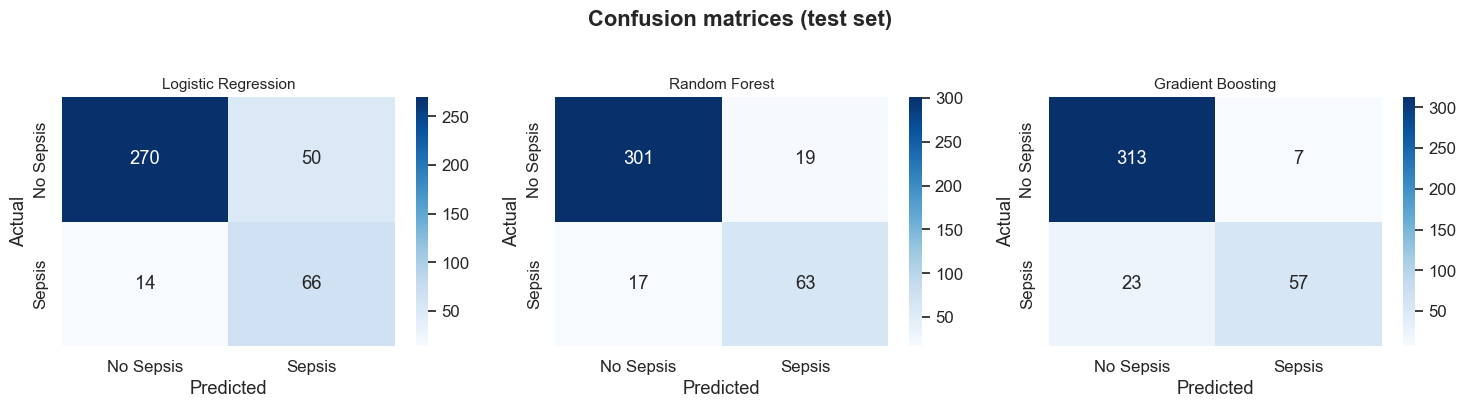

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Sepsis', 'Sepsis'],
                yticklabels=['No Sepsis', 'Sepsis'])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion matrices (test set)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Calibration Plot

A well-calibrated model means: when it predicts 70% probability of sepsis, roughly 70% of those patients actually have sepsis. This matters clinically because poorly calibrated probabilities mislead decision-making.

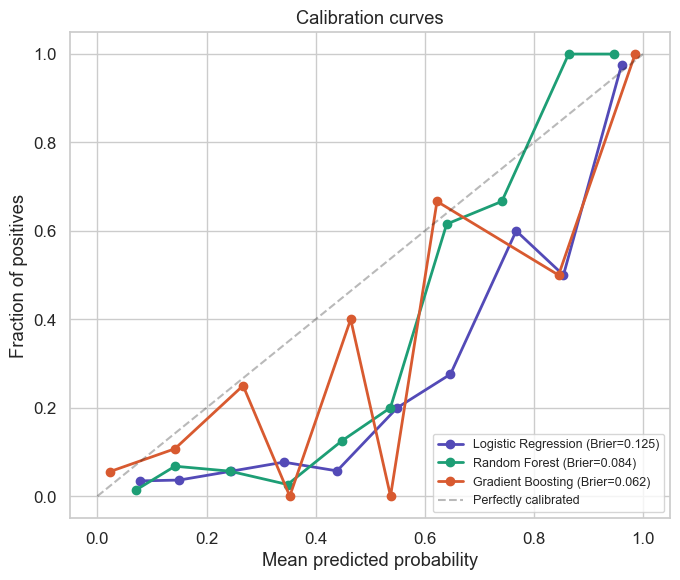

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))

for (name, r), c in zip(results.items(), colours):
    prob_true, prob_pred = calibration_curve(y_test, r['y_prob'], n_bins=10, strategy='uniform')
    ax.plot(prob_pred, prob_true, marker='o', label=f"{name} (Brier={r['brier']:.3f})", color=c, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration curves')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../assets/calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Detailed Classification Reports

In [15]:
for name, r in results.items():
    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, r['y_pred'], target_names=['No Sepsis', 'Sepsis']))


 Logistic Regression
              precision    recall  f1-score   support

   No Sepsis       0.95      0.84      0.89       320
      Sepsis       0.57      0.82      0.67        80

    accuracy                           0.84       400
   macro avg       0.76      0.83      0.78       400
weighted avg       0.87      0.84      0.85       400


 Random Forest
              precision    recall  f1-score   support

   No Sepsis       0.95      0.94      0.94       320
      Sepsis       0.77      0.79      0.78        80

    accuracy                           0.91       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.91      0.91      0.91       400


 Gradient Boosting
              precision    recall  f1-score   support

   No Sepsis       0.93      0.98      0.95       320
      Sepsis       0.89      0.71      0.79        80

    accuracy                           0.93       400
   macro avg       0.91      0.85      0.87       400
weighted avg    

## 6. Feature Importance

Understanding which features drive predictions is critical for clinical trust. We use two approaches:
1. **Model-native importance** (Gini / coefficients)
2. **Permutation importance** (model-agnostic — measures AUROC drop when each feature is shuffled)

Best model by AUROC: Random Forest (0.9060)



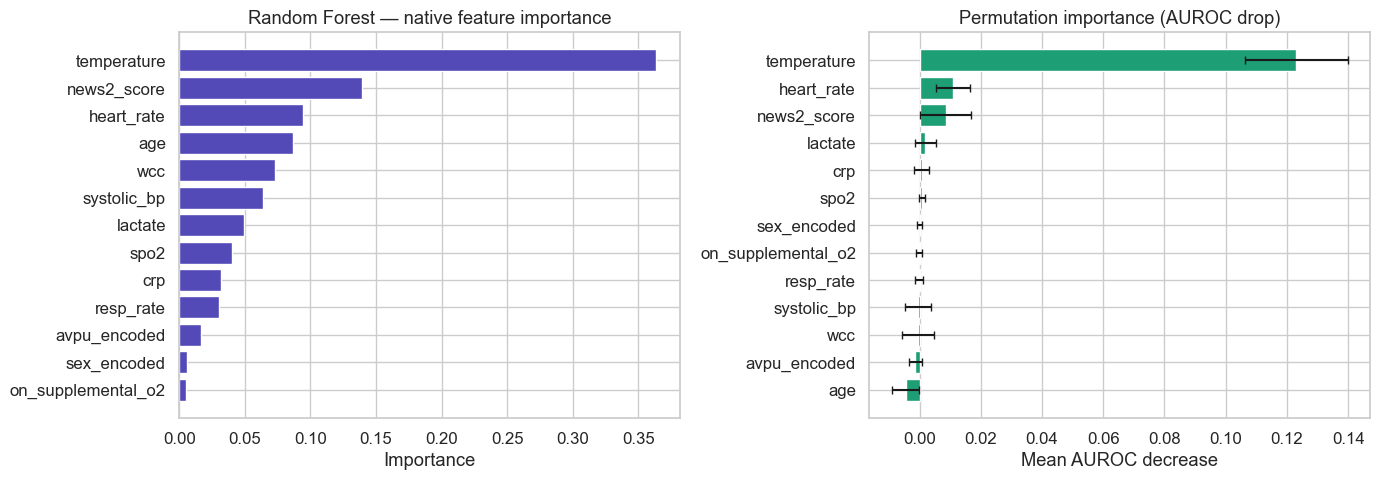

In [16]:
best_name = max(results, key=lambda k: results[k]['auroc'])
best_model = fitted_models[best_name]
print(f"Best model by AUROC: {best_name} ({results[best_name]['auroc']:.4f})\n")

if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importance = np.abs(best_model.coef_[0])
else:
    importance = np.zeros(len(feature_cols))

imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importance}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(imp_df['feature'], imp_df['importance'], color='#534AB7', edgecolor='white')
axes[0].set_title(f'{best_name} — native feature importance')
axes[0].set_xlabel('Importance')

perm_result = permutation_importance(
    best_model, X_test_scaled, y_test,
    n_repeats=20, random_state=RANDOM_STATE, scoring='roc_auc'
)
perm_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=True)

axes[1].barh(perm_df['feature'], perm_df['importance_mean'],
             xerr=perm_df['importance_std'], color='#1D9E75', edgecolor='white', capsize=3)
axes[1].set_title('Permutation importance (AUROC drop)')
axes[1].set_xlabel('Mean AUROC decrease')

plt.tight_layout()
plt.savefig('../assets/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. NEWS2 Score as Baseline Classifier

To contextualise our ML models, we compare against the raw NEWS2 score as a standalone predictor. The RCP uses NEWS2 >= 5 for urgent clinical review, and >= 7 for emergency response.

NEWS2 score alone — AUROC: 0.8508
Best ML model     — AUROC: 0.9060
Improvement:        +0.0551



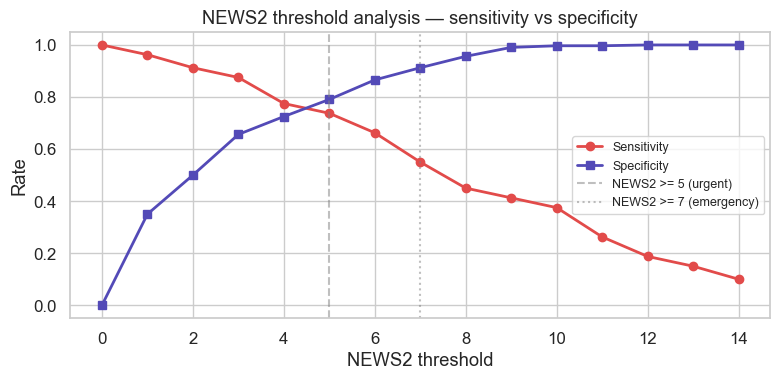

In [17]:
news2_auroc = roc_auc_score(y_test, X_test['news2_score'])
print(f"NEWS2 score alone — AUROC: {news2_auroc:.4f}")
print(f"Best ML model     — AUROC: {results[best_name]['auroc']:.4f}")
print(f"Improvement:        +{results[best_name]['auroc'] - news2_auroc:.4f}\n")

thresholds = range(0, 15)
fig, ax = plt.subplots(figsize=(8, 4))

sensitivities, specificities = [], []
for t in thresholds:
    pred = (X_test['news2_score'] >= t).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    tn = ((pred == 0) & (y_test == 0)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivities.append(sens)
    specificities.append(spec)

ax.plot(list(thresholds), sensitivities, 'o-', label='Sensitivity', color='#E24B4A', linewidth=2)
ax.plot(list(thresholds), specificities, 's-', label='Specificity', color='#534AB7', linewidth=2)
ax.axvline(x=5, color='grey', linestyle='--', alpha=0.5, label='NEWS2 >= 5 (urgent)')
ax.axvline(x=7, color='grey', linestyle=':', alpha=0.5, label='NEWS2 >= 7 (emergency)')
ax.set_xlabel('NEWS2 threshold')
ax.set_ylabel('Rate')
ax.set_title('NEWS2 threshold analysis — sensitivity vs specificity')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../assets/news2_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Fair baseline comparison: what if a clinician built a simple LR model
# on NEWS2 + labs? How much does the full ML approach actually gain?
# ---------------------------------------------------------------------
# This separates two distinct questions:
#   1. How much improvement comes from having labs at all?
#   2. How much additional gain comes from using a complex ML algorithm?

from sklearn.linear_model import LogisticRegression

# Build the simple "clinician-friendly" model: just NEWS2 + 3 labs
simple_features = ['news2_score', 'wcc', 'lactate', 'crp']

lr_simple = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
lr_simple.fit(X_train[simple_features], y_train)
y_prob_simple = lr_simple.predict_proba(X_test[simple_features])[:, 1]

# Bootstrap CI for this simple baseline
lo_s, med_s, hi_s = bootstrap_ci(y_test, y_prob_simple, roc_auc_score)

# Pull together for side-by-side comparison
print(f"{'Approach':<35s}  {'AUROC (95% CI)'}")
print("-" * 70)
print(f"{'NEWS2 alone (no labs)':<35s}  {news2_auroc:.3f}")
print(f"{'Simple LR on NEWS2 + labs':<35s}  {med_s:.3f} ({lo_s:.3f}–{hi_s:.3f})")
print(f"{'Full ML (' + best_name + ')':<35s}  "
      f"{results[best_name]['auroc']:.3f}")

# What does the ML add beyond labs-only?
ml_over_labs = results[best_name]['auroc'] - med_s
labs_over_news2 = med_s - news2_auroc

print(f"\n🔹 Gain from adding labs (→ simple LR):  +{labs_over_news2:.3f}")
print(f"🔹 Additional gain from ML algorithm:   +{ml_over_labs:.3f}")

Approach                             AUROC (95% CI)
----------------------------------------------------------------------
NEWS2 alone (no labs)                0.851
Simple LR on NEWS2 + labs            0.855 (0.798–0.899)
Full ML (Random Forest)              0.906

🔹 Gain from adding labs (→ simple LR):  +0.004
🔹 Additional gain from ML algorithm:   +0.051


## 8. Save Best Model

In [19]:
model_path = '../models/best_model.joblib'
joblib.dump({
    'model': best_model,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'label_encoders': {'avpu': le_avpu, 'sex': le_sex},
    'metadata': {
        'model_name': best_name,
        'auroc': results[best_name]['auroc'],
        'auprc': results[best_name]['auprc'],
        'train_size': len(X_train),
        'test_size': len(X_test),
    }
}, model_path)
print(f"Saved best model ({best_name}) -> {model_path}")

Saved best model (Random Forest) -> ../models/best_model.joblib


## 9. Limitations & Next Steps

### Limitations

- **Synthetic data:** Vital-sign and laboratory distributions are modelled on published NEWS2 and Sepsis-3 reference ranges. Although severity-linked inter-feature correlations and normothermic sepsis (~35%) are simulated, synthetic data cannot capture real-world complexity such as comorbidity interactions, medication effects, or measurement noise. Performance on this cohort is therefore likely to be optimistic compared with real clinical datasets (published MIMIC-IV sepsis models typically achieve AUROC 0.78–0.88).

- **Single time-point:** Each patient is represented by a snapshot of vitals and labs. Real sepsis detection benefits substantially from *trends* (deteriorating vital-sign trajectories over hours), which this model cannot access.

- **No external validation:** These metrics reflect performance within the synthetic cohort only. External validation on real patient data is essential before any clinical interpretation.

- **Overlapping confidence intervals between models:** The 95% CIs for Logistic Regression, Random Forest, and Gradient Boosting all overlap (see Section 4). The Random Forest's higher point estimate should not be interpreted as statistically superior to the other models on this sample size.

- **Feature correlation limits permutation importance:** Several vital signs are strongly correlated (e.g. respiratory rate, heart rate, NEWS2 score), which reduces each individual feature's apparent importance under permutation testing. Native impurity-based importance gives a more complete picture of which signals the model uses.

### Key Finding: Where Does the Predictive Value Come From?

One of the more informative comparisons in this project is the **simple logistic regression baseline** using only NEWS2 + the three lab markers (Section 7). It achieves an AUROC within ~0.004 of NEWS2 alone — meaning that on this cohort, *adding lab markers via a linear model does not meaningfully improve discrimination*. The full ML model's additional gain (+0.051 AUROC) therefore comes from capturing non-linear interactions between vital signs rather than from lab data per se.

This is clinically relevant: it suggests that any gain from sending extra blood tests upstream of a linear risk score would be modest, while the real modelling value lies in how vital-sign combinations are represented.

### Next Steps

1. **Validation on real data** — MIMIC-IV or eICU Collaborative Research Database (both publicly accessible to credentialled users). External validation is the single most important next step.

2. **Temporal modelling** — Incorporate sequential vital signs using LSTM or Temporal Fusion Transformer architectures to capture deterioration trajectories rather than single time-points.

3. **Calibration improvement** — Apply Platt scaling or isotonic regression, particularly to the Random Forest (which shows some miscalibration at mid-range probabilities in Section 5.3).

4. **Decision-curve analysis** — Calculate net clinical benefit across plausible intervention thresholds, rather than relying on AUROC alone. This is more directly clinically meaningful.

5. **Fairness audit** — Stratify performance across age and sex subgroups to identify any disparities before considering deployment.

6. **Lightweight deployment prototype** — Build a FastAPI endpoint that accepts NEWS2 parameters and returns a calibrated sepsis risk score, to demonstrate the end-to-end pipeline.